In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Load Data From Kaggle
https://www.kaggle.com/datasets/datascikhan/e-commerce-customer-segmentation-2026

In [67]:
from pathlib import Path

path = kagglehub.dataset_download(
    "datascikhan/e-commerce-customer-segmentation-2026"
)
print("Path to dataset files:", path)

data_dir = Path(path)
csv_files = list(data_dir.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir}")

df = pd.read_csv(csv_files[0])

Path to dataset files: /Users/yezawmyint/.cache/kagglehub/datasets/datascikhan/e-commerce-customer-segmentation-2026/versions/1


# Understanding data

In [68]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
# Check Duplication
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count:,}\n")

# Column Information
print("*"*30)
print(" Column Information")
print("*"*30)

column_info = pd.DataFrame({
    "Column": df.columns.astype(str).values,
    "Data Type": df.dtypes.astype(str).values,
    "Duplicate": df.duplicated().sum()
})

display(column_info)

Rows: 50,000
Columns: 53
Duplicate Rows: 0

******************************
 Column Information
******************************


,Column,Data Type,Duplicate
0,customer_id,str,0
1,customer_segment,str,0
2,segment_category,str,0
3,age,int64,0
4,age_group,str,0
5,gender,str,0
6,country,str,0
7,city,str,0
8,income_bracket,str,0
9,education_level,str,0


## Check Data Validation

In [69]:
# Missing values
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})
print("*"*30)
print(" Missing Value Summary")
print("*"*30)

display(
    missing_summary
    .sort_values("Missing Values", ascending=False)
    .head(10)
)

******************************
 Missing Value Summary
******************************


,Missing Values,Missing %
preferred_category_3,33257,66.51
preferred_category_2,16743,33.49
social_media_presence,12420,24.84
loyalty_tier,1272,2.54
customer_id,0,0.00
rfm_score,0,0.00
click_through_rate,0,0.00
conversion_rate,0,0.00
customer_lifetime_value_usd,0,0.00
customer_acquisition_cost_usd,0,0.00


In [70]:
# Check Duplication
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count:,}")


Duplicate Rows: 0


In [71]:
summary_cols = [
    "age",
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "days_since_last_purchase"
]

display(
    df[summary_cols]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
age,50000.0,45.65,18.37,18.00,30.00,45.00,60.00,84.00
tenure_months,50000.0,59.75,34.31,1.00,30.00,60.00,90.00,119.00
total_purchases,50000.0,99.42,57.78,0.00,49.00,99.00,150.00,199.00
avg_order_value_usd,50000.0,505.37,285.60,10.05,259.07,504.79,752.70,999.99
total_spent_usd,50000.0,50266.55,44071.21,0.00,13893.58,37541.62,76811.24,198574.14
days_since_last_purchase,50000.0,62.97,93.28,0.00,2.00,19.00,77.00,365.00


In [72]:
# Top 5 rows
df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [73]:
# Bottom 5 rows
df.tail()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
49995,CUST-049996,Small Business,Low Value,22,18-24,Female,United States,San Antonio,50K-75K,PhD,...,Very Low,Inactive,Fair,High,Need Attention,High Profit,Low,Occasional Buyer,Multi-Device,Low CLV
49996,CUST-049997,Small Business,High Value Inactive,24,18-24,Male,Brazil,Rio de Janeiro,25K-50K,PhD,...,Very High,Dormant,Excellent,Low,Champions,High Profit,Medium,Regular Buyer,Multi-Device,High CLV
49997,CUST-049998,Consumer,High Value Inactive,29,25-34,Female,France,Strasbourg,100K-150K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
49998,CUST-049999,Consumer,High Value Active,74,65+,Male,Italy,Catania,100K-150K,Bachelors,...,High,Active,Good,Low,Champions,High Profit,Low,Frequent Buyer,Multi-Device,High CLV
49999,CUST-050000,Consumer,High Value Inactive,77,65+,Female,United Arab Emirates,Sharjah,75K-100K,Masters,...,Very High,Inactive,Excellent,Low,Loyal,High Profit,Low,Occasional Buyer,Desktop-First,High CLV


# Exploratory Data Analysis

This section looks at the customers, their purchase activity, and simple patterns in the data.

## Descriptive Statistics

First, I summarize the main customer and purchase variables before looking at charts.

### Customer Profile

This part shows who the customers are by age group, gender, income, country, and device.

In [74]:
customer_profile_summary = pd.DataFrame({
    "Metric": [
        "Unique customers",
        "Most common age group",
        "Most common gender",
        "Most common income bracket",
        "Top country",
        "Most used device"
    ],
    "Value": [
        df["customer_id"].nunique(),
        df["age_group"].mode().iat[0],
        df["gender"].mode().iat[0],
        df["income_bracket"].mode().iat[0],
        df["country"].mode().iat[0],
        df["device_used"].mode().iat[0]
    ]
})

display(customer_profile_summary)

,Metric,Value
0,Unique customers,50000
1,Most common age group,65+
2,Most common gender,Female
3,Most common income bracket,0-25K
4,Top country,United States
5,Most used device,Desktop


In [75]:
plt.style.use('ggplot')

In [76]:
def show_fig():
    plt.tight_layout()
    plt.show()
plot_no = 1

## Customer Segment Distribution

This chart shows how customers are distributed across the main business segments. The largest segment is highlighted for quick comparison.

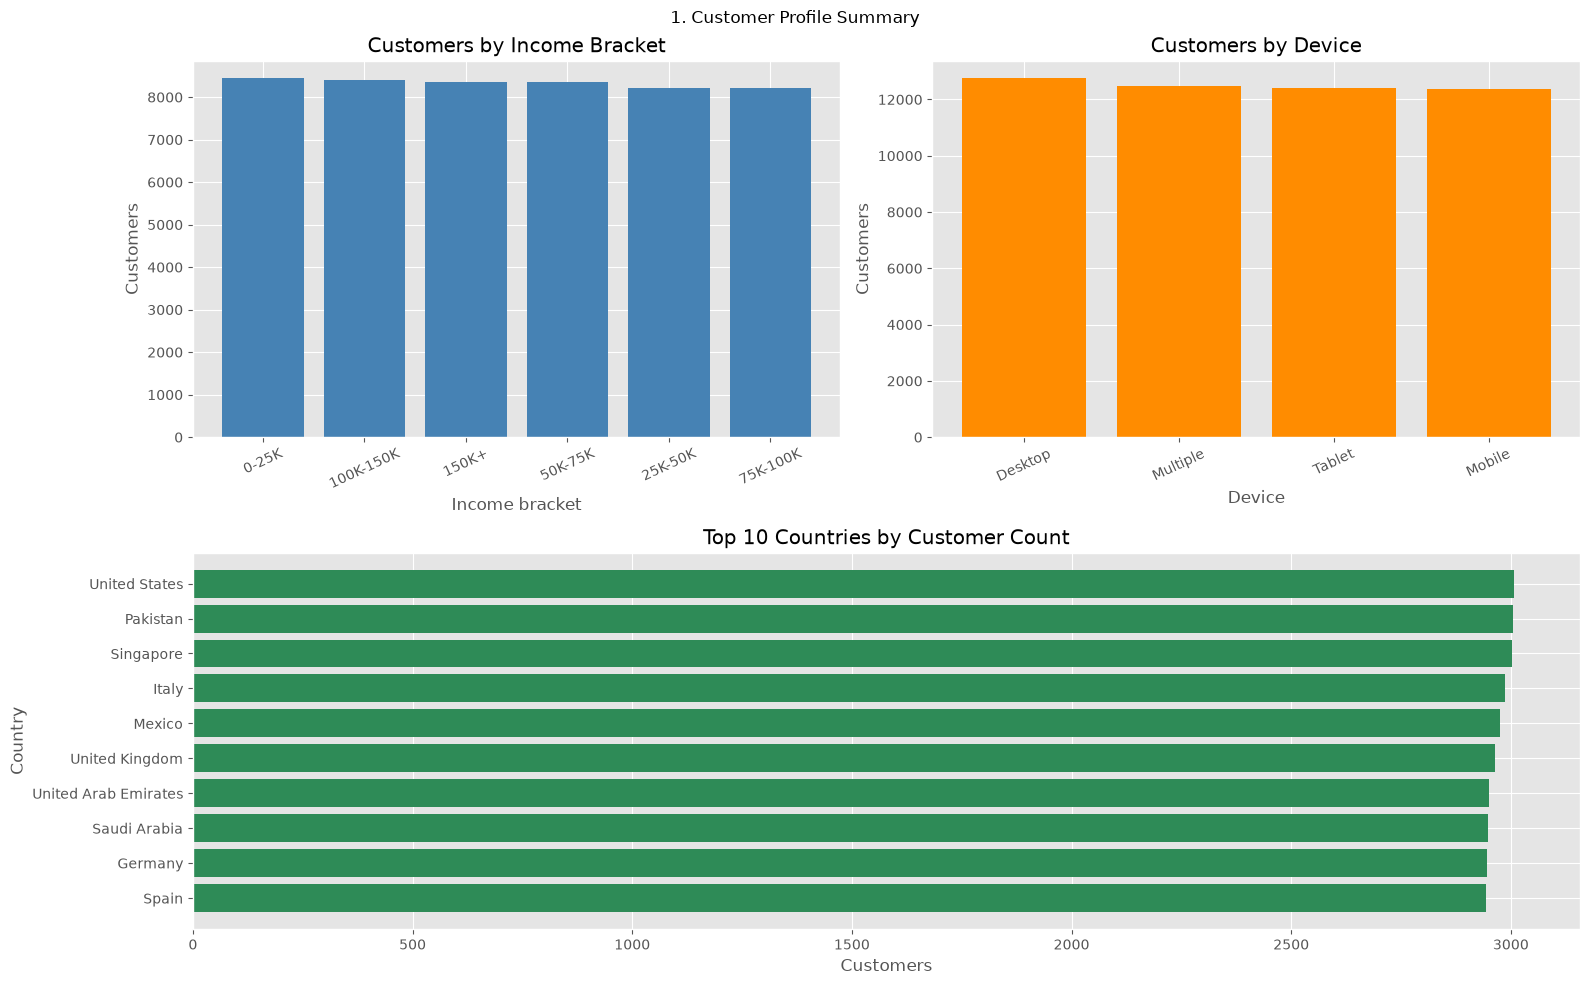

In [77]:
fig = plt.figure(figsize=(16, 10))
grid = fig.add_gridspec(2, 2)

income_ax = fig.add_subplot(grid[0, 0])
income_counts = df["income_bracket"].value_counts()
income_ax.bar(income_counts.index, income_counts.values, color="steelblue")
income_ax.set_title("Customers by Income Bracket")
income_ax.set_xlabel("Income bracket")
income_ax.set_ylabel("Customers")
income_ax.tick_params(axis="x", rotation=25)


device_ax = fig.add_subplot(grid[0, 1])
device_counts = df["device_used"].value_counts()
device_ax.bar(device_counts.index, device_counts.values, color="darkorange")
device_ax.set_title("Customers by Device")
device_ax.set_xlabel("Device")
device_ax.set_ylabel("Customers")
device_ax.tick_params(axis="x", rotation=25)


country_ax = fig.add_subplot(grid[1, :])
country_counts = df["country"].value_counts().head(10).sort_values()
country_ax.barh(country_counts.index, country_counts.values, color="seagreen")
country_ax.set_title("Top 10 Countries by Customer Count")
country_ax.set_xlabel("Customers")
country_ax.set_ylabel("Country")

fig.suptitle(f"{plot_no}. Customer Profile Summary")
plot_no += 1
show_fig()

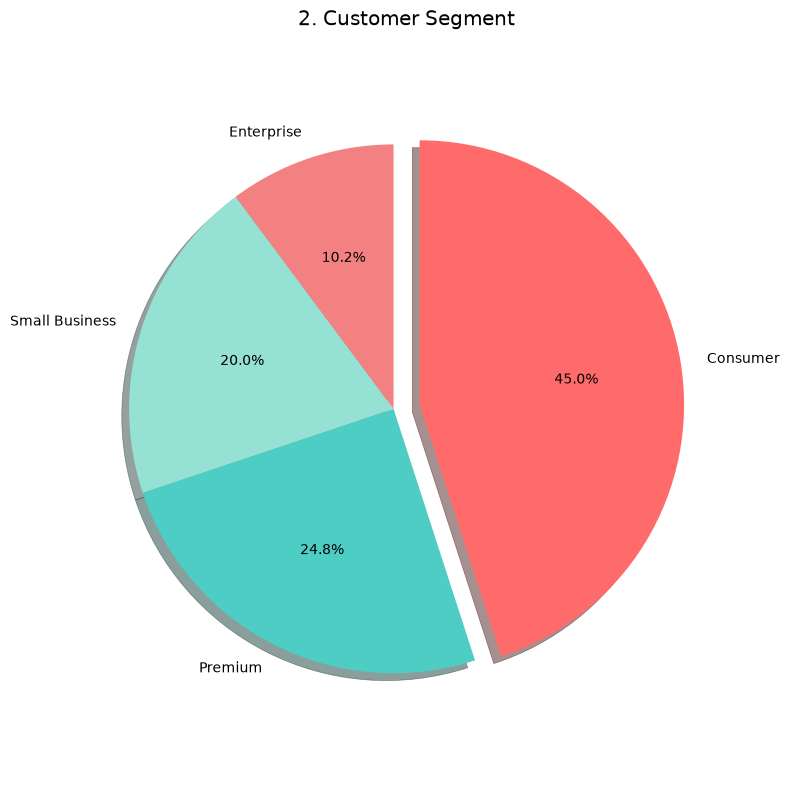

In [78]:
# Sort categories so the largest segment appears first.
segment_counts = df["customer_segment"].value_counts().sort_values(ascending=False)
colors = ["#FF6B6B", "#4ECDC4", "#95E1D3", "#F38181"][:len(segment_counts)]
explode = [0.1] + [0] * (len(segment_counts) - 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    segment_counts.values,
    labels=segment_counts.index,
    colors=colors,
    explode=explode,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    shadow=True
)
ax.set_title(f"{plot_no}. Customer Segment")
ax.axis("equal")
show_fig()
plot_no += 1

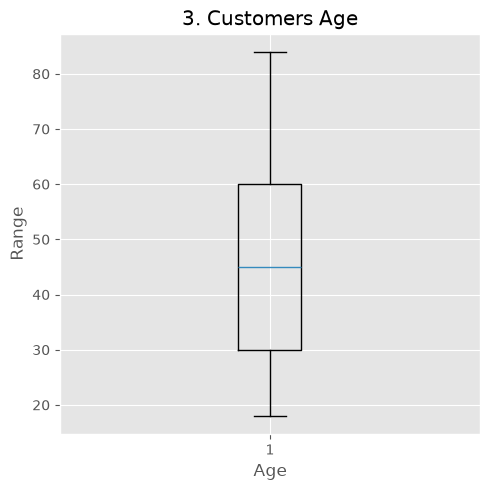

In [79]:
# Outliers
plt.figure(figsize=(5,5))
plt.boxplot(df['age'], showfliers=True)
plt.xlabel("Age")
plt.ylabel("Range")
plt.title(f'{plot_no}. Customers Age')
show_fig()
plot_no+=1

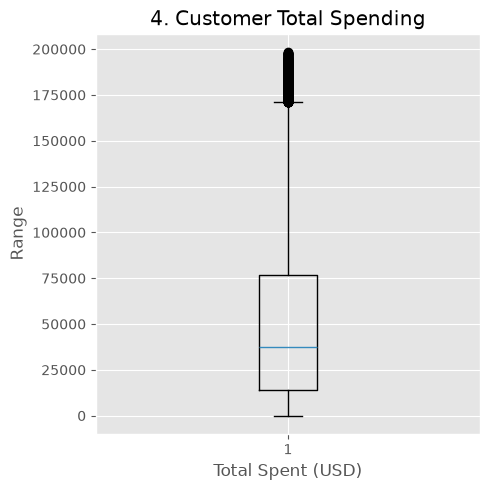

In [80]:
# Outliers in total spending
plt.figure(figsize=(5, 5))
plt.boxplot(df["total_spent_usd"], showfliers=True)

plt.xlabel("Total Spent (USD)")
plt.ylabel("Range")
plt.title(f"{plot_no}. Customer Total Spending")
show_fig()
plot_no += 1

## Education Level Distribution

This chart compares the education levels represented in the customer base. The largest group is highlighted for quick comparison.

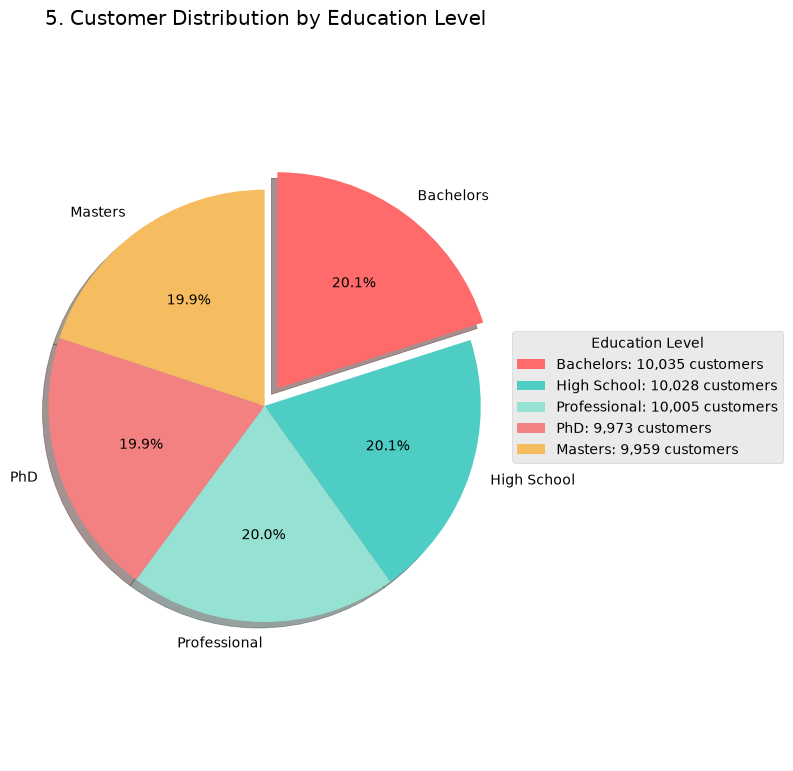

In [81]:
# Sort education levels so the largest group appears first.
education_counts = df["education_level"].value_counts().sort_values(ascending=False)
colors = ["#FF6B6B", "#4ECDC4", "#95E1D3", "#F38181", "#F6BD60"][:len(education_counts)]
explode = [0.1] + [0] * (len(education_counts) - 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    education_counts.values,
    labels=education_counts.index,
    colors=colors,
    explode=explode,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    shadow=True
)
ax.set_title(f"{plot_no}. Customer Distribution by Education Level")
ax.legend(
    title="Education Level",
    labels=[
        f"{level}: {count:,} customers"
        for level, count in education_counts.items()
    ],
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
ax.axis("equal")
show_fig()
plot_no += 1

### Purchase Behavior

This part summarizes how often customers purchase, how much they spend, and how recently they purchased.

In [82]:
purchase_cols = [
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "purchase_frequency",
    "days_since_last_purchase"
]

purchase_summary = pd.DataFrame({
    "Metric": [
        "Average tenure (months)",
        "Average total purchases",
        "Average order value (USD)",
        "Average total spent (USD)",
        "Average days since last purchase"
    ],
    "Value": [
        df["tenure_months"].mean(),
        df["total_purchases"].mean(),
        df["avg_order_value_usd"].mean(),
        df["total_spent_usd"].mean(),
        df["days_since_last_purchase"].mean()
    ]
})

purchase_summary["Value"] = purchase_summary["Value"].round(2)
display(purchase_summary)

,Metric,Value
0,Average tenure (months),59.75
1,Average total purchases,99.42
2,Average order value (USD),505.37
3,Average total spent (USD),50266.55
4,Average days since last purchase,62.97


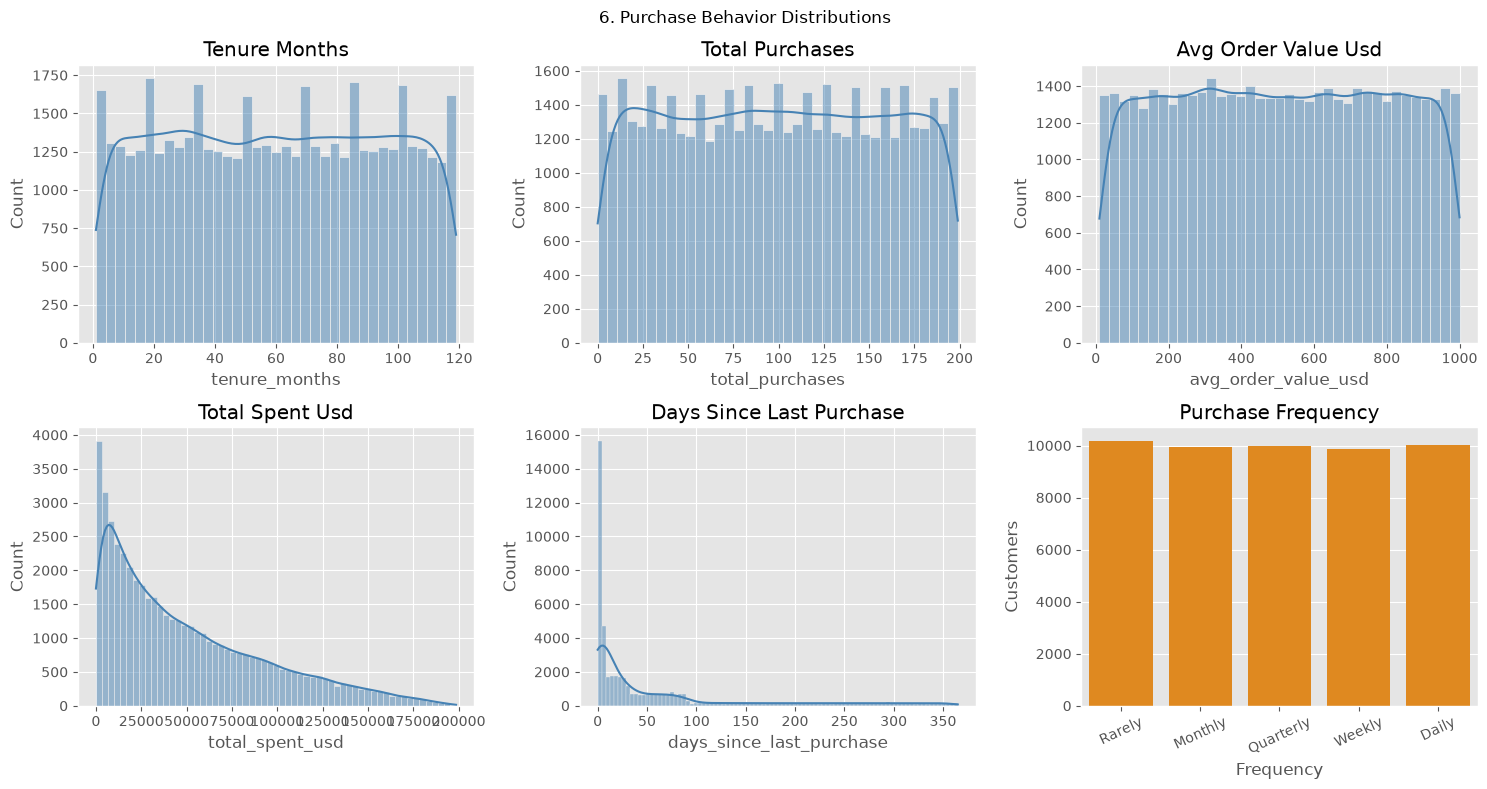

In [83]:
numeric_purchase_cols = [
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "days_since_last_purchase"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flat[:5], numeric_purchase_cols):
    sns.histplot(df[column], kde=True, ax=ax, color="steelblue")
    ax.set_title(column.replace("_", " ").title())

frequency_order = ["Rarely", "Monthly", "Quarterly", "Weekly", "Daily"]
sns.countplot(
    data=df,
    x="purchase_frequency",
    order=[value for value in frequency_order if value in df["purchase_frequency"].unique()],
    ax=axes[1, 2],
    color="darkorange"
)
axes[1, 2].set_title("Purchase Frequency")
axes[1, 2].set_xlabel("Frequency")
axes[1, 2].set_ylabel("Customers")
axes[1, 2].tick_params(axis="x", rotation=25)

fig.suptitle(f"{plot_no}. Purchase Behavior Distributions")
plot_no += 1
show_fig()

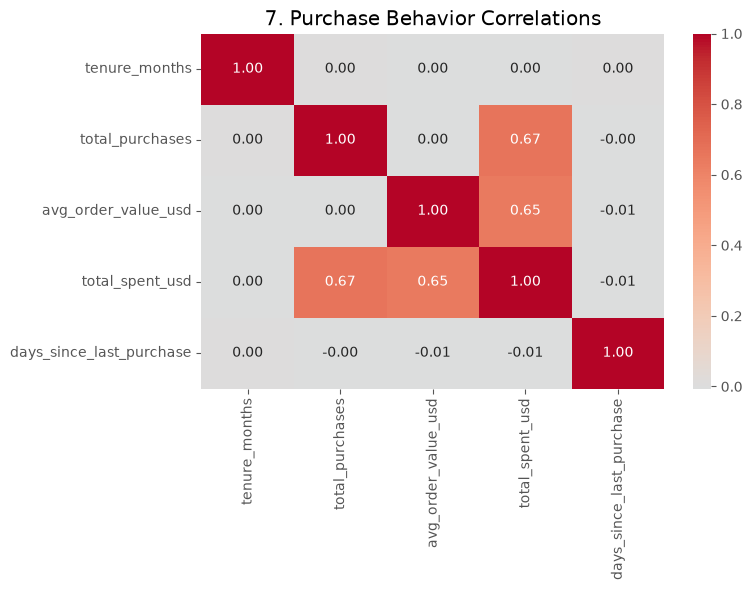

In [84]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_purchase_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title(f"{plot_no}. Purchase Behavior Correlations")
show_fig()
plot_no += 1

In [85]:
frequency_order = {
    "Rarely": 1,
    "Monthly": 2,
    "Quarterly": 3,
    "Weekly": 4,
    "Daily": 5
}

frequency_numeric = (
    df["purchase_frequency"]
    .astype("string")
    .str.strip()
    .map(frequency_order)
)

if frequency_numeric.isna().any():
    unexpected = df.loc[
        frequency_numeric.isna(),
        "purchase_frequency"
    ].dropna().unique().tolist()
    raise ValueError(f"Unexpected values: {unexpected}")

df["frequency_group"] = pd.qcut(
    frequency_numeric.rank(method="first"),
    3,
    labels=["Low", "Medium", "High"]
)

df["recency_group"] = pd.qcut(
    df["days_since_last_purchase"],
    3,
    labels=["Recent", "Moderate", "Inactive"],
    duplicates="drop"
)

behavior_summary = (
    df.groupby(["frequency_group", "recency_group"], observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_spent=("total_spent_usd", "mean"),
        avg_order_value=("avg_order_value_usd", "mean")
    )
    .reset_index()
)

behavior_summary[["avg_spent", "avg_order_value"]] = (
    behavior_summary[["avg_spent", "avg_order_value"]].round(2)
)

display(behavior_summary)

,frequency_group,recency_group,customers,avg_spent,avg_order_value
0,Low,Moderate,6483,50101.01,508.19
1,Low,Inactive,10184,49760.75,499.88
2,Medium,Recent,2304,52083.72,517.58
3,Medium,Moderate,8028,50284.57,502.47
4,Medium,Inactive,6334,50884.86,509.45
5,High,Recent,14774,50146.03,505.16
6,High,Moderate,1893,50138.06,510.57


# Customer Value, Risk, and Segmentation Analysis

The next sections translate the descriptive EDA into actionable customer insights: RFM value, churn risk, profitability, segment performance, and data-driven customer clusters.

In [86]:
required_columns = {
    "customer_id",
    "days_since_last_purchase",
    "total_purchases",
    "total_spent_usd",
    "avg_order_value_usd",
    "customer_segment",
    "churn_risk_category",
    "profitability_category"
}
missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

rfm_columns = {
    "days_since_last_purchase": "recency",
    "total_purchases": "frequency",
    "total_spent_usd": "monetary"
}
rfm = df[["customer_id", *rfm_columns]].rename(columns=rfm_columns).copy()


def quantile_score(series, labels):
    return pd.qcut(
        series.rank(method="first"),
        q=len(labels),
        labels=labels
    ).astype(int)


rfm["recency_score"] = quantile_score(rfm["recency"], [5, 4, 3, 2, 1])
rfm["frequency_score"] = quantile_score(rfm["frequency"], [1, 2, 3, 4, 5])
rfm["monetary_score"] = quantile_score(rfm["monetary"], [1, 2, 3, 4, 5])
rfm_score_columns = ["recency_score", "frequency_score", "monetary_score"]
rfm["rfm_score"] = rfm[rfm_score_columns].astype(str).agg("".join, axis=1)

high_recency = rfm["recency_score"] >= 4
low_recency = rfm["recency_score"] <= 2
high_frequency = rfm["frequency_score"] >= 4
low_frequency = rfm["frequency_score"] <= 2
high_monetary = rfm["monetary_score"] >= 4

rfm["rfm_category"] = np.select(
    [
        high_recency & high_frequency & high_monetary,
        high_recency & low_frequency,
        low_recency & high_monetary,
        low_recency & low_frequency
    ],
    ["Champions", "New or Promising", "At Risk High Value", "Hibernating"],
    default="Loyal Customers"
)

rfm_category_summary = (
    rfm["rfm_category"]
    .value_counts()
    .rename_axis("RFM Category")
    .reset_index(name="Customers")
)
display(rfm_category_summary)

,RFM Category,Customers
0,Loyal Customers,21235
1,New or Promising,8003
2,At Risk High Value,7915
3,Hibernating,7411
4,Champions,5436


## RFM and Customer Value

,customers,avg_recency_days,avg_purchases,avg_spent_usd,avg_annualized_value
calculated_rfm_category,,,,,
Champions,5436,2.25,161.19,106336.43,60294.30
At Risk High Value,7915,144.96,139.81,95656.23,52345.65
Loyal Customers,21235,41.46,112.87,42168.56,22527.88
New or Promising,8003,2.28,39.43,19945.40,11155.33
Hibernating,7411,147.13,37.20,16609.23,8899.57


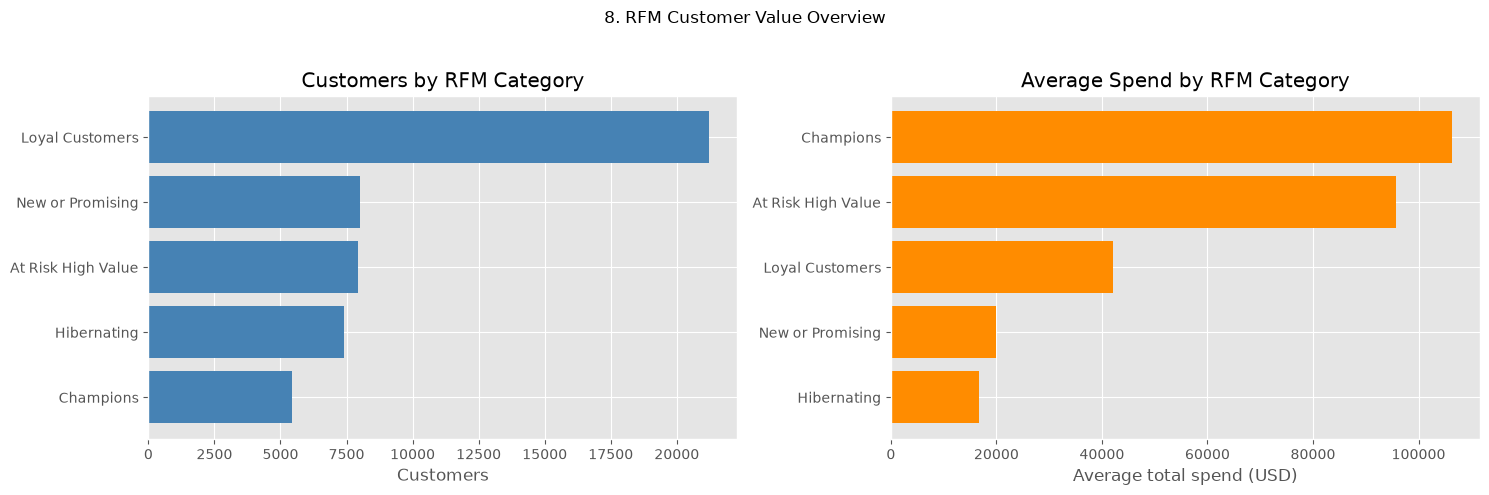

In [87]:
rfm_summary_columns = ["customer_id", "rfm_score", "rfm_category"]
calculated_rfm = rfm[rfm_summary_columns].rename(
    columns={
        "rfm_score": "calculated_rfm_score",
        "rfm_category": "calculated_rfm_category"
    }
)
customer_analysis = df.join(
    calculated_rfm.set_index("customer_id"),
    on="customer_id",
    how="left",
    validate="one_to_one"
)

customer_analysis["annualized_value_proxy"] = (
    customer_analysis["total_spent_usd"]
    .div(customer_analysis["tenure_months"].clip(lower=1))
    .mul(12)
    .round(2)
)

segment_summary = (
    customer_analysis
    .groupby("calculated_rfm_category", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_recency_days=("days_since_last_purchase", "mean"),
        avg_purchases=("total_purchases", "mean"),
        avg_spent_usd=("total_spent_usd", "mean"),
        avg_annualized_value=("annualized_value_proxy", "mean")
    )
    .sort_values("avg_spent_usd", ascending=False)
    .round(2)
)

display(segment_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
segment_counts = rfm["rfm_category"].value_counts().sort_values()
axes[0].barh(segment_counts.index, segment_counts.values, color="steelblue")
axes[0].set_title("Customers by RFM Category")
axes[0].set_xlabel("Customers")

plot_data = segment_summary.sort_values("avg_spent_usd")
axes[1].barh(plot_data.index, plot_data["avg_spent_usd"], color="darkorange")
axes[1].set_title("Average Spend by RFM Category")
axes[1].set_xlabel("Average total spend (USD)")

plot_no = globals().get("plot_no", 1)
fig.suptitle(f"{plot_no}. RFM Customer Value Overview")
plot_no += 1
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Churn Risk, Profitability, and Business Actions

These comparisons identify where retention effort and marketing budget are most likely to matter.

,customers,avg_recency_days,avg_total_spent_usd,total_revenue_usd
churn_risk_category,,,,
Very Low,20604,28.37,51552.95,1.062197e+09
Low,17203,60.07,50379.87,8.666849e+08
Medium,9491,109.21,48711.93,4.623250e+08
High,2395,178.55,46331.65,1.109643e+08
Very High,307,216.65,36339.32,1.115617e+07


,customers,avg_total_spent_usd,avg_order_value_usd,avg_purchases
profitability_category,,,,
High Profit,48770,51522.86,511.70,101.68
Medium Profit,514,786.00,243.01,16.32
Low Profit,357,396.83,148.74,9.04
Break Even,61,146.11,54.62,4.85
Loss Making,298,10.02,441.64,0.26


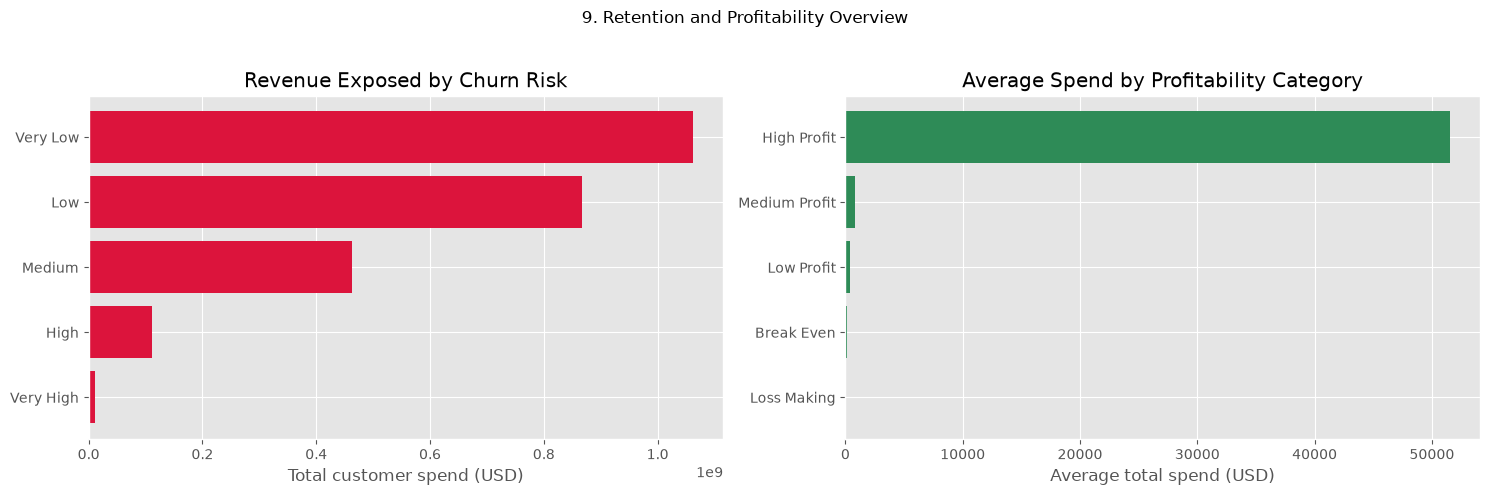

Suggested actions:
- Prioritize high-value customers in elevated churn-risk categories for personalized retention campaigns.
- Nurture New or Promising customers toward repeat purchase behavior.
- Use Champions for referrals, early access, and loyalty advocacy.
- Re-engage Hibernating customers only when the expected campaign value exceeds contact cost.


In [88]:
churn_summary = (
    customer_analysis
    .groupby("churn_risk_category", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_recency_days=("days_since_last_purchase", "mean"),
        avg_total_spent_usd=("total_spent_usd", "mean"),
        total_revenue_usd=("total_spent_usd", "sum")
    )
    .sort_values("total_revenue_usd", ascending=False)
    .round(2)
)

profitability_summary = (
    customer_analysis
    .groupby("profitability_category", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_total_spent_usd=("total_spent_usd", "mean"),
        avg_order_value_usd=("avg_order_value_usd", "mean"),
        avg_purchases=("total_purchases", "mean")
    )
    .sort_values("avg_total_spent_usd", ascending=False)
    .round(2)
)

display(churn_summary)
display(profitability_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
churn_plot = churn_summary.sort_values("total_revenue_usd")
axes[0].barh(churn_plot.index, churn_plot["total_revenue_usd"], color="crimson")
axes[0].set_title("Revenue Exposed by Churn Risk")
axes[0].set_xlabel("Total customer spend (USD)")

profit_plot = profitability_summary.sort_values("avg_total_spent_usd")
axes[1].barh(profit_plot.index, profit_plot["avg_total_spent_usd"], color="seagreen")
axes[1].set_title("Average Spend by Profitability Category")
axes[1].set_xlabel("Average total spend (USD)")

plot_no = globals().get("plot_no", 1)
fig.suptitle(f"{plot_no}. Retention and Profitability Overview")
plot_no += 1
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Suggested actions:")
print("- Prioritize high-value customers in elevated churn-risk categories for personalized retention campaigns.")
print("- Nurture New or Promising customers toward repeat purchase behavior.")
print("- Use Champions for referrals, early access, and loyalty advocacy.")
print("- Re-engage Hibernating customers only when the expected campaign value exceeds contact cost.")

## Customer Clustering Experiment

K-means provides an exploratory, data-driven alternative to the source segment labels. The clusters are descriptive and should be validated with business outcomes before production use.

,customers,avg_recency_days,avg_purchases,avg_order_value_usd,avg_total_spent_usd
behavior_cluster,,,,,
2,13313,38.06,151.15,734.88,109489.44
3,6576,270.20,92.94,471.46,42282.78
4,13361,28.54,42.75,658.28,28787.07
1,16750,28.89,106.06,214.28,23463.81


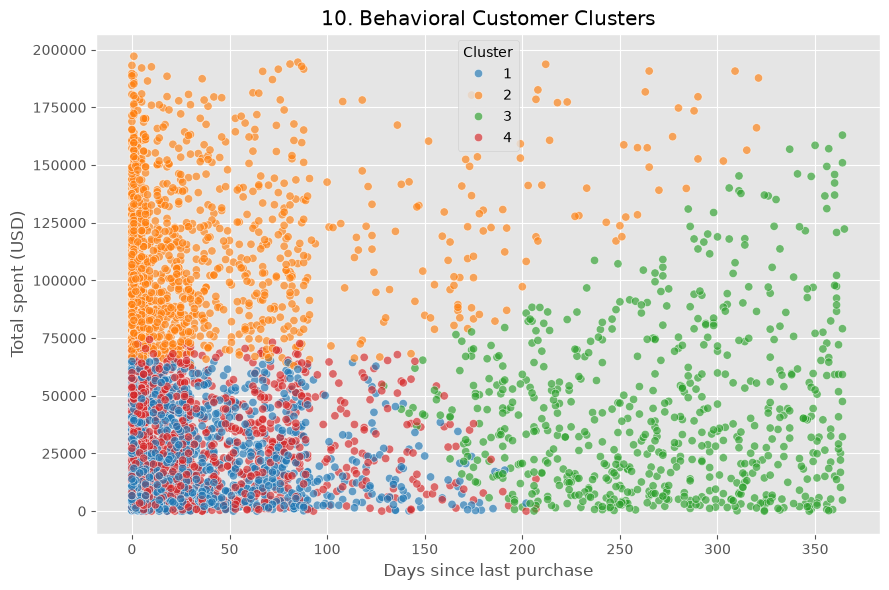

In [89]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "days_since_last_purchase",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd"
]
cluster_data = customer_analysis[cluster_features]
scaled_features = StandardScaler().fit_transform(cluster_data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_analysis["behavior_cluster"] = kmeans.fit_predict(scaled_features) + 1

cluster_profile = (
    customer_analysis
    .groupby("behavior_cluster", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_recency_days=("days_since_last_purchase", "mean"),
        avg_purchases=("total_purchases", "mean"),
        avg_order_value_usd=("avg_order_value_usd", "mean"),
        avg_total_spent_usd=("total_spent_usd", "mean")
    )
    .sort_values("avg_total_spent_usd", ascending=False)
    .round(2)
)

display(cluster_profile)

cluster_sample = customer_analysis.sample(
    min(5000, len(customer_analysis)),
    random_state=42
)
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=cluster_sample,
    x="days_since_last_purchase",
    y="total_spent_usd",
    hue="behavior_cluster",
    palette="tab10",
    alpha=0.65,
    ax=ax
)

plot_no = globals().get("plot_no", 1)
ax.set_title(f"{plot_no}. Behavioral Customer Clusters")
ax.set_xlabel("Days since last purchase")
ax.set_ylabel("Total spent (USD)")
ax.legend(title="Cluster")
plot_no += 1
fig.tight_layout()
plt.show()

## Executive Summary

In [90]:
total_customers = customer_analysis["customer_id"].nunique()
total_revenue = customer_analysis["total_spent_usd"].sum()
champions = customer_analysis["calculated_rfm_category"].eq("Champions").sum()
at_risk = customer_analysis["calculated_rfm_category"].eq("At Risk High Value").sum()
high_churn_revenue = churn_summary.loc[
    churn_summary.index.isin(["High", "Very High"]),
    "total_revenue_usd"
].sum()

print("=" * 65)
print("E-COMMERCE CUSTOMER SEGMENTATION: EXECUTIVE SUMMARY")
print("=" * 65)
print(f"Customers analyzed: {total_customers:,}")
print(f"Total historical customer spend: ${total_revenue:,.2f}")
print(f"Champions: {champions:,} ({champions / total_customers:.1%})")
print(f"High-value customers at risk: {at_risk:,} ({at_risk / total_customers:.1%})")
print(
    "Revenue from High and Very High churn-risk customers: "
    f"${high_churn_revenue:,.2f} ({high_churn_revenue / total_revenue:.1%})"
)

key_interpretations = [
    "Champions combine recent activity, high purchase frequency, and the highest average spend.",
    "At Risk High Value customers are the clearest retention priority because their spend remains high despite poor recency.",
    "Hibernating customers have both low purchase frequency and low spend, so broad discounts may be inefficient.",
    "Clusters support differentiated messaging, but stability and campaign response should be tested before deployment."
]
print("\nKey interpretation:")
for number, interpretation in enumerate(key_interpretations, start=1):
    print(f"{number}. {interpretation}")

recommended_next_analyses = [
    "Test retention campaigns with an A/B design and measure incremental revenue.",
    "Build a supervised churn model using a time-based validation split.",
    "Estimate CLV with margin, retention probability, and discount cost rather than revenue alone.",
    "Monitor segment migration monthly to detect changes in loyalty and churn risk."
]
print("\nRecommended next analyses:")
for recommendation in recommended_next_analyses:
    print(f"- {recommendation}")
print("=" * 65)

E-COMMERCE CUSTOMER SEGMENTATION: EXECUTIVE SUMMARY
Customers analyzed: 50,000
Total historical customer spend: $2,513,327,307.80
Champions: 5,436 (10.9%)
High-value customers at risk: 7,915 (15.8%)
Revenue from High and Very High churn-risk customers: $122,120,469.06 (4.9%)

Key interpretation:
1. Champions combine recent activity, high purchase frequency, and the highest average spend.
2. At Risk High Value customers are the clearest retention priority because their spend remains high despite poor recency.
3. Hibernating customers have both low purchase frequency and low spend, so broad discounts may be inefficient.
4. Clusters support differentiated messaging, but stability and campaign response should be tested before deployment.

Recommended next analyses:
- Test retention campaigns with an A/B design and measure incremental revenue.
- Build a supervised churn model using a time-based validation split.
- Estimate CLV with margin, retention probability, and discount cost rather tha